# Motivation

I have this dataset from Safegraph of all cellphone carrier stores in the U.S. from 2021. It was previously manipulated to have columns indicating if the store was one the carriers of interst (Boost Mobile, AT&T, Cricket, MetroPCS, Sprint, Verizon, and TMobile). 

Now that I have more experience with data manipulation, cleaning, exploration, and data science/predictive analytics than I did in 2021, I want to see if I can answer what are the differences in neighborhood demographics by cellphone carrier types, can I explain/predict the presence of budget carriers using these variables, and what are the types of neighborhoods for each carrier when we apply regionalization or market segmentation techniques to these data?

# Data importing and inspecting

In [1]:
import pandas as pd
import geopandas as gpd

# Load a local CSV file into a DataFrame
Cellphone_df = pd.read_csv('/Users/gusstephens/Desktop/old Desktop/CellphoneClass/data-raw/Cell_Phone_Electronics_SafeGraph.csv')

# Preview the first 5 rows of data
print(Cellphone_df.head())

# print list of state column
print(Cellphone_df['state'].unique())

# count number of states in state column
print(Cellphone_df['state'].nunique())


                          location_name            brands  longitude  \
0                      Pirum Consulting               NaN -80.652814   
1                      Verizon Wireless  Verizon Wireless -81.160215   
2                          Dish Network               NaN -86.213804   
3                         U.S. Cellular     U.S. Cellular -78.969511   
4  Hagan Business Machines of Meadville               NaN -80.160494   

    latitude     street_address        city state  postal_code opened_on  \
0  41.037619    467 Oakridge Dr    Boardman    OH        44512       NaN   
1  34.077386  173 Columbiana Dr    Columbia    SC        29212       NaN   
2  35.363897   303 N Jackson St   Tullahoma    TN        37388       NaN   
3  39.061850      107 S Main St  Moorefield    WV        26836       NaN   
4  41.638242        77 Mead Ave   Meadville    PA        16335       NaN   

   closed_on  MetroPCS  Cricket  Boost  ATT  Sprint  TMobile  Verizon  
0        NaN         0        0      0

In [2]:
# filter out PR (Puerto Rico) from Cellphone_df
Cellphone_df = Cellphone_df[Cellphone_df['state'] != 'PR']

# filter out VI (Virgin Islands) from Cellphone_df
Cellphone_df = Cellphone_df[Cellphone_df['state'] != 'VI']


In [3]:
# count number of carriers by type using columns (MetroPCS, Cricket, Boost, ATT, Sprint, TMobile, Verizon)
carrier_cols = ['MetroPCS', 'Cricket', 'Boost', 'ATT', 'Sprint', 'TMobile', 'Verizon']
carrier_counts = Cellphone_df[carrier_cols].sum()
print(carrier_counts)


MetroPCS    7477
Cricket     4633
Boost       5840
ATT         5375
Sprint       450
TMobile     7003
Verizon     2249
dtype: int64


MetroPCS has the most locations but how are they distributed across the U.S.?

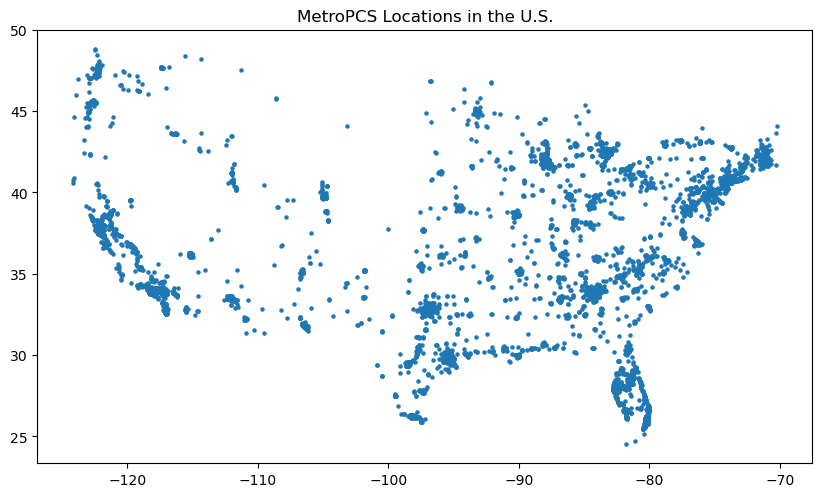

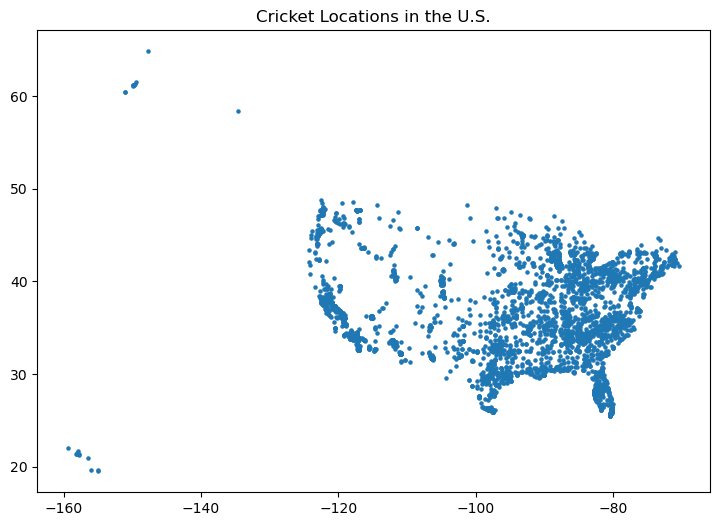

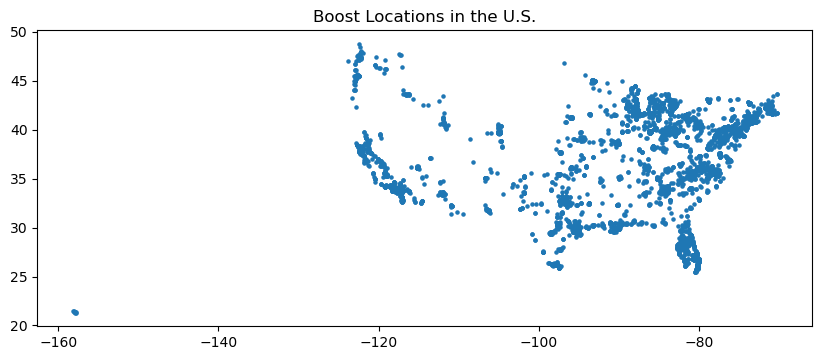

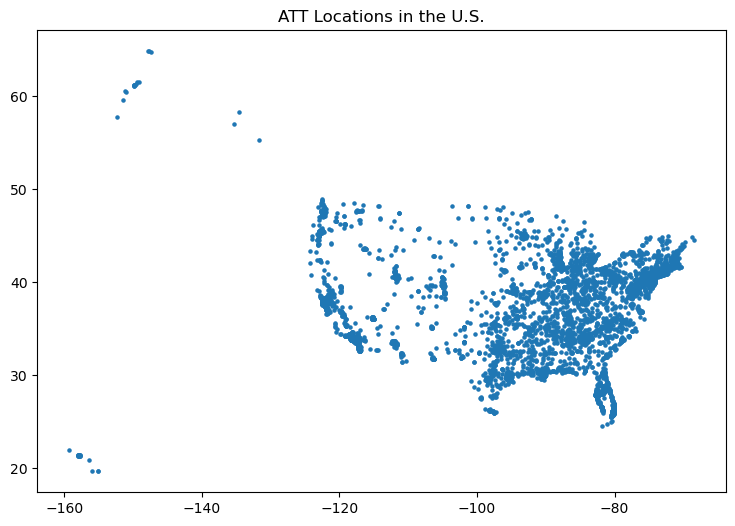

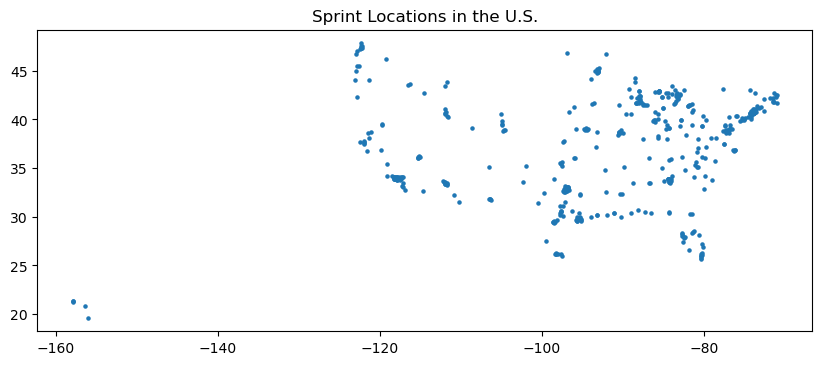

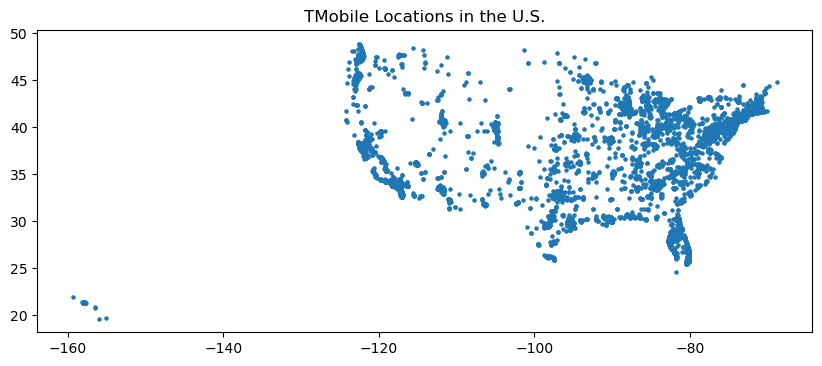

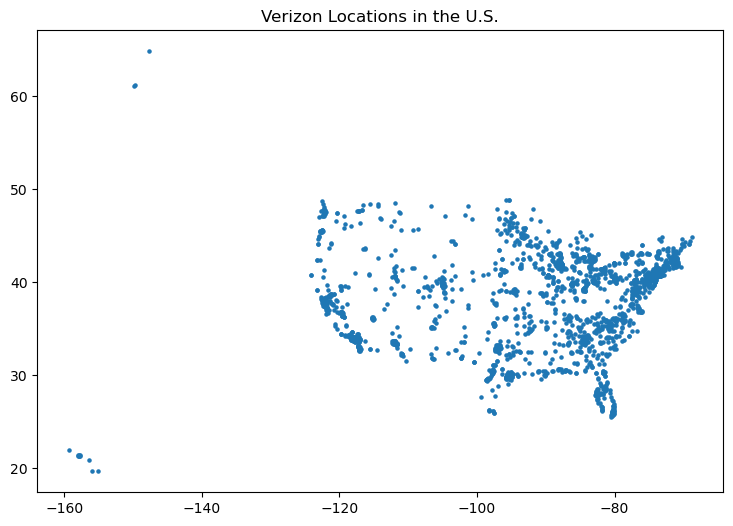

In [4]:
# Create separate maps of MetroPCS, Cricket, Boost, ATT, Sprint, TMobile, Verizon in the U.S.
Cellphone_gdf = gpd.GeoDataFrame(
    Cellphone_df,
    geometry=gpd.points_from_xy(Cellphone_df['longitude'], Cellphone_df['latitude']),
    crs='EPSG:4326'
)

for carrier in carrier_cols:
    carrier_gdf = Cellphone_gdf[Cellphone_gdf[carrier] == 1]
    ax = carrier_gdf.plot(markersize=5, figsize=(10, 6))
    ax.set_title(f'{carrier} Locations in the U.S.')

Boost Mobile is sparse in the upper Mountain West. Sprint was likely closing down/going out of business at this time. All other carriers look well distributed across the U.S..

In [5]:
# Rename Boost to Boost Mobile and ATT to AT&T

Cellphone_df = Cellphone_df.rename(columns={'Boost': 'Boost Mobile', 'ATT': 'AT&T'})

# Adding Census Data to our Data Frame

In [6]:
import pytidycensus as tc
import geopandas as gpd
import pandas as pd

# Census API key to use pytidycensus
# hard-code it here
tc.set_census_api_key("add your Census API key when replicating")


# make a 50 States + DC 2020 Census Tracts gdf called US_Tracts2020
state_fips = [
    '01','02','04','05','06','08','09','10','11','12','13','15','16','17','18','19',
    '20','21','22','23','24','25','26','27','28','29','30','31','32','33','34','35',
    '36','37','38','39','40','41','42','44','45','46','47','48','49','50','51','53',
    '54','55','56'
]

# From the 2020-2024 ACS, attach the median household income, population density, number of children per household, marriage rate, share of single person households, % NH Black, % NH White, % Hispanic all races, % NH Asian
acs_vars = {
    "median_hh_income": "B19013_001",
    "total_pop": "B01003_001",
    "total_households": "B11001_001",
    "single_person_hh": "B11001_008",
    "own_children": "B09002_001",
    "married_male": "B12001_004",
    "married_female": "B12001_013",
    "pop_15plus": "B12001_001",
    "total_race_universe": "B03002_001",
    "nh_white": "B03002_003",
    "nh_black": "B03002_004",
    "nh_asian": "B03002_006",
    "hispanic_any_race": "B03002_012",
}

acs_list = []
for state in state_fips:
    acs = tc.get_acs(
        geography="tract",
        variables=acs_vars,
        state=state,
        year=2024,
        output="wide",
        geometry=True   # pull tract boundaries directly from the ACS/TIGER vintage instead of the 2020 Decennial
    )
    acs_list.append(acs)

US_Tracts2024 = pd.concat(acs_list, ignore_index=True)
US_Tracts2024 = gpd.GeoDataFrame(US_Tracts2024, geometry='geometry')

# make sure US_Tracts2024 is in a sensical projection system.
print(US_Tracts2024.crs)
US_Tracts2024 = US_Tracts2024.to_crs(epsg=5070)

# derive the rates/percentages from raw counts
US_Tracts2024['area_sqkm'] = US_Tracts2024.geometry.area / 1_000_000
US_Tracts2024['pop_density'] = US_Tracts2024['total_pop'] / US_Tracts2024['area_sqkm']
US_Tracts2024['children_per_hh'] = US_Tracts2024['own_children'] / US_Tracts2024['total_households']
US_Tracts2024['marriage_rate'] = (US_Tracts2024['married_male'] + US_Tracts2024['married_female']) / US_Tracts2024['pop_15plus']
US_Tracts2024['single_person_share'] = US_Tracts2024['single_person_hh'] / US_Tracts2024['total_households']
US_Tracts2024['pct_nh_white'] = US_Tracts2024['nh_white'] / US_Tracts2024['total_race_universe']
US_Tracts2024['pct_nh_black'] = US_Tracts2024['nh_black'] / US_Tracts2024['total_race_universe']
US_Tracts2024['pct_nh_asian'] = US_Tracts2024['nh_asian'] / US_Tracts2024['total_race_universe']
US_Tracts2024['pct_hispanic'] = US_Tracts2024['hispanic_any_race'] / US_Tracts2024['total_race_universe']

# turn Cellphone_df into a spatial df using longitude and latitude. Project it to US Conic Equal Albers.
Cellphone_gdf = gpd.GeoDataFrame(
    Cellphone_df,
    geometry=gpd.points_from_xy(Cellphone_df['longitude'], Cellphone_df['latitude']),
    crs='EPSG:4326'
)
Cellphone_gdf = Cellphone_gdf.to_crs(epsg=5070)

# Let's do a spatial join of Cellphone_df onto US_Tracts2024. The new object is called US_Tracts_Carriers. There should be a join count for each carrier within each tract.
carrier_cols = ['MetroPCS', 'Cricket', 'Boost Mobile', 'AT&T', 'Sprint', 'TMobile', 'Verizon']

joined = gpd.sjoin(Cellphone_gdf, US_Tracts2024, predicate='within', how='inner')
tract_carrier_sums = joined.groupby('GEOID')[carrier_cols].sum().reset_index()

US_Tracts_Carriers = US_Tracts2024.merge(tract_carrier_sums, on='GEOID', how='left')
US_Tracts_Carriers[carrier_cols] = US_Tracts_Carriers[carrier_cols].fillna(0)

/var/folders/4m/ym9gy1qd72l1_pyq4z0__91c0000gn/T/ipykernel_2384/2435857544.py:1: UserWarning: Mapping functions unavailable due to import error: NameError. To use mapping features, ensure all dependencies are properly installed: pip install pytidycensus[map]
  import pytidycensus as tc


Census API key has been set for this session.
Getting data from the 2020-2024 5-year ACS
Getting data from the 2020-2024 5-year ACS
Getting data from the 2020-2024 5-year ACS
Getting data from the 2020-2024 5-year ACS
Getting data from the 2020-2024 5-year ACS
Getting data from the 2020-2024 5-year ACS
Getting data from the 2020-2024 5-year ACS


/opt/anaconda3/envs/datasci/lib/python3.13/site-packages/pytidycensus/utils.py:976: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace(missing_codes, pd.NA, inplace=True)


Getting data from the 2020-2024 5-year ACS
Getting data from the 2020-2024 5-year ACS
Getting data from the 2020-2024 5-year ACS
Getting data from the 2020-2024 5-year ACS
Getting data from the 2020-2024 5-year ACS
Getting data from the 2020-2024 5-year ACS
Getting data from the 2020-2024 5-year ACS
Getting data from the 2020-2024 5-year ACS
Getting data from the 2020-2024 5-year ACS
Getting data from the 2020-2024 5-year ACS
Getting data from the 2020-2024 5-year ACS
Getting data from the 2020-2024 5-year ACS
Getting data from the 2020-2024 5-year ACS
Getting data from the 2020-2024 5-year ACS
Getting data from the 2020-2024 5-year ACS
Getting data from the 2020-2024 5-year ACS
Getting data from the 2020-2024 5-year ACS
Getting data from the 2020-2024 5-year ACS
Getting data from the 2020-2024 5-year ACS
Getting data from the 2020-2024 5-year ACS
Getting data from the 2020-2024 5-year ACS
Getting data from the 2020-2024 5-year ACS
Getting data from the 2020-2024 5-year ACS
Getting dat

In [7]:
Cellphone_gdf = Cellphone_gdf.to_crs(epsg=5070)

# now re-run the join with matching CRSs
joined = gpd.sjoin(Cellphone_gdf, US_Tracts2024, predicate='within', how='inner')

In [8]:
# let's check how many were not joined out of curiosity. It's probably not a deal breaker but would be good to know count by carrier and overall share of unmatched by carrier.

# totals from the original point data, before the join
original_counts = Cellphone_gdf[carrier_cols].sum()

# totals from the joined data, after the inner join
joined_counts = joined[carrier_cols].sum()

# unmatched = original minus what made it into the join
unmatched_counts = original_counts - joined_counts
unmatched_share = unmatched_counts / original_counts

unmatched_summary = pd.DataFrame({
    'original': original_counts,
    'joined': joined_counts,
    'unmatched': unmatched_counts,
    'unmatched_share': unmatched_share
})

print(unmatched_summary)

# overall total rows dropped (not per-carrier, just raw point count)
print(f"\nTotal points: {len(Cellphone_gdf)}")
print(f"Points joined: {len(joined)}")
print(f"Points unmatched: {len(Cellphone_gdf) - len(joined)}")
print(f"Overall unmatched share: {(len(Cellphone_gdf) - len(joined)) / len(Cellphone_gdf):.2%}")

              original  joined  unmatched  unmatched_share
MetroPCS          7477    7471          6         0.000802
Cricket           4633    4632          1         0.000216
Boost Mobile      5840    5834          6         0.001027
AT&T              5375    5374          1         0.000186
Sprint             450     450          0         0.000000
TMobile           7003    7000          3         0.000428
Verizon           2249    2249          0         0.000000

Total points: 86523
Points joined: 86494
Points unmatched: 29
Overall unmatched share: 0.03%


Number of unmatched points: 29
                             location_name             city state   latitude  \
2264                      Cricket Wireless        Brentwood    NY  40.778932   
2590   Metro by T Mobile Authorized Dealer        Brentwood    NY  40.781343   
5258                                  AT&T        Brentwood    NY  40.781670   
6595   Metro by T Mobile Authorized Dealer        Brentwood    NY  40.759288   
7437          T Mobile Authorized Retailer        Brentwood    NY  40.778010   
8342                        T Mobile Store        Brentwood    NY  40.779374   
9151                      Cellulars & More        Brentwood    NY  40.786664   
12465                         DISH Network        Brentwood    NY  40.776665   
12994  Metro by T Mobile Authorized Dealer        Brentwood    NY  40.799307   
15594                         Boost Mobile        Brentwood    NY  40.786630   
18190                     We Sell Cellular        Brentwood    NY  40.775377   
25339    

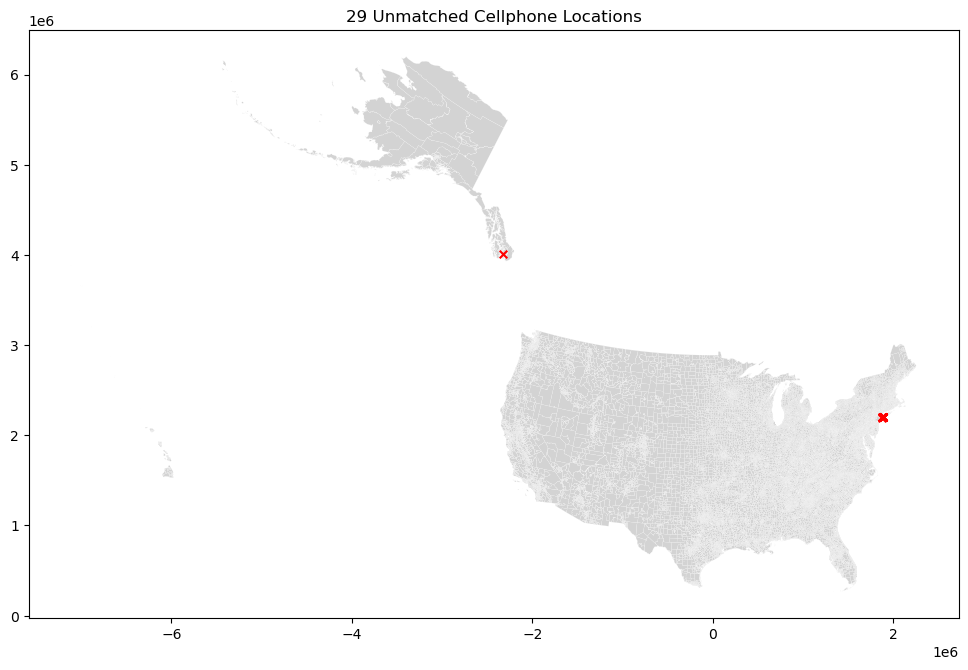

In [9]:

# let's map the 29 unmatched points
import matplotlib.pyplot as plt

# find rows in Cellphone_gdf that did NOT make it into the joined result
unmatched_points = Cellphone_gdf[~Cellphone_gdf.index.isin(joined.index)]

print(f"Number of unmatched points: {len(unmatched_points)}")
print(unmatched_points[['location_name', 'city', 'state', 'latitude', 'longitude']])

# plot the unmatched points against tract boundaries for context
fig, ax = plt.subplots(figsize=(12, 8))
US_Tracts2024.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.1)
unmatched_points.plot(ax=ax, color='red', markersize=30, marker='x')
ax.set_title(f'{len(unmatched_points)} Unmatched Cellphone Locations')
plt.show()

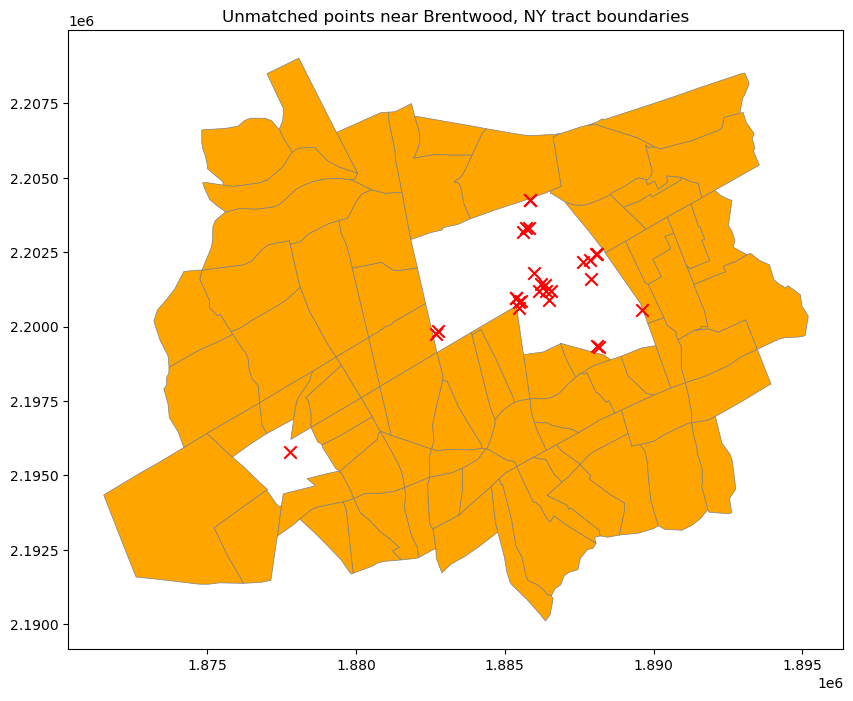

In [16]:

# zoom into the Brentwood cluster to see if points sit near tract boundaries
brentwood_area = unmatched_points[unmatched_points['city'].isin(['Brentwood', 'Wyandanch', 'North Bay Shore'])]

minx, miny, maxx, maxy = brentwood_area.total_bounds
buffer = 2000  # 2km buffer in meters, since we're in EPSG:5070

fig, ax = plt.subplots(figsize=(10, 10))
US_Tracts2024.cx[minx-buffer:maxx+buffer, miny-buffer:maxy+buffer].plot(
    ax=ax, facecolor='orange', edgecolor='gray', linewidth=0.5
)
brentwood_area.plot(ax=ax, color='red', markersize=80, marker='x')
ax.set_title('Unmatched points near Brentwood, NY tract boundaries')
plt.show()

This appears to be an issue with the Census Bureau's TIGER files for the 2024 ACS vintage not the code or API. I'm going to join them to the nearest tracts and move onto the descriptive stats.

In [17]:
# final join: catch genuinely broken-geometry cases with a generous but bounded cutoff
joined_final = gpd.sjoin_nearest(Cellphone_gdf, US_Tracts2024, max_distance=1500, how='inner')

still_unmatched = Cellphone_gdf[~Cellphone_gdf.index.isin(joined_final.index)]
print(f"Unmatched after final join: {len(still_unmatched)}")

Unmatched after final join: 0


# Descriptive Statistics aka Q1: How do neigbhorhoods (tracts) differ by carrier?

In [18]:
# Compute the tract level descriptive statistics for each carrier 
# demographic variables to summarize
demo_vars = [
    'median_hh_income', 'pop_density', 'children_per_hh', 'marriage_rate',
    'single_person_share', 'pct_nh_white', 'pct_nh_black', 'pct_nh_asian', 'pct_hispanic'
]

# for each carrier, compute mean/median/mode/std across tracts where that carrier is present
results = {}

for carrier in carrier_cols:
    present_tracts = US_Tracts_Carriers[US_Tracts_Carriers[carrier] > 0]
    
    stats = pd.DataFrame({
        'median': present_tracts[demo_vars].median(),
        'std': present_tracts[demo_vars].std(),
        'n_tracts': present_tracts[demo_vars].count()
    })
    
    results[carrier] = stats

# combine into one multi-level dataframe: carrier -> demographic variable -> stat
carrier_demo_stats = pd.concat(results, axis=0)
carrier_demo_stats.index.names = ['carrier', 'variable']


In [19]:
pd.set_option('display.max_rows', None)
print(carrier_demo_stats)

                                       median           std  n_tracts
carrier      variable                                                
MetroPCS     median_hh_income         62519.5  27370.935558      6850
             pop_density          1726.462509   5717.417414      6889
             children_per_hh         0.492746      0.245069      6884
             marriage_rate           0.409976      0.114266      6884
             single_person_share     0.301915        0.1331      6884
             pct_nh_white            0.298821      0.267483      6884
             pct_nh_black            0.110932      0.247998      6884
             pct_nh_asian            0.019027      0.084584      6884
             pct_hispanic            0.255829      0.284597      6884
Cricket      median_hh_income         61378.0  24521.951426      4433
             pop_density          1095.785943   3236.905791      4452
             children_per_hh         0.492895      0.232475      4450
             marriag

In [20]:
# variables that are proportions and should display as percentages
pct_vars = [
    'children_per_hh',  # actually a ratio, not a %, keep as-is — see note below
    'marriage_rate', 'single_person_share',
    'pct_nh_white', 'pct_nh_black', 'pct_nh_asian', 'pct_hispanic'
]
pct_vars = [v for v in pct_vars if v != 'children_per_hh']  # exclude non-percentage ratio

def format_stats(row):
    variable = row.name[1]  # second level of the multi-index (carrier, variable)
    formatted = row.copy()
    if variable in pct_vars:
        for col in ['median','std']:
            formatted[col] = f"{row[col]:.1%}"
    else:
        for col in ['median','std']:
            formatted[col] = f"{row[col]:,.2f}"
    return formatted

carrier_demo_stats_display = carrier_demo_stats.apply(format_stats, axis=1)
carrier_demo_stats_display

median        std  n_tracts
carrier      variable                                           
MetroPCS     median_hh_income     62,519.50  27,370.94      6850
             pop_density           1,726.46   5,717.42      6889
             children_per_hh           0.49       0.25      6884
             marriage_rate            41.0%      11.4%      6884
             single_person_share      30.2%      13.3%      6884
             pct_nh_white             29.9%      26.7%      6884
             pct_nh_black             11.1%      24.8%      6884
             pct_nh_asian              1.9%       8.5%      6884
             pct_hispanic             25.6%      28.5%      6884
Cricket      median_hh_income     61,378.00  24,521.95      4433
             pop_density           1,095.79   3,236.91      4452
             children_per_hh           0.49       0.23      4450
             marriage_rate            43.5%      11.1%      4450
             single_person_share      30.6%      12.3%      4450
             pct_nh_white             43.4%      29.0%      4450
             pct_nh_black              6.8%      20.5%      4450
             pct_nh_asian              1.4%       8.5%      4450
             pct_hispanic             20.5%      28.9%      4450
Boost Mobile median_hh_income     59,670.00  24,290.97      5273
             pop_density           1,639.93   6,081.58      5300
             children_per_hh           0.50       0.24      5298
             marriage_rate            40.5%      11.2%      5298
             single_person_share      31.1%      13.1%      5298
             pct_nh_white             30.9%      27.4%      5298
             pct_nh_black             12.7%      25.2%      5298
             pct_nh_asian              1.4%       7.1%      5298
             pct_hispanic             23.6%      28.3%      5298
AT&T         median_hh_income     79,233.50  38,765.35      5142
             pop_density             816.53   4,105.97      5166
             children_per_hh           0.46       0.22      5156
             marriage_rate            48.5%      12.2%      5158
             single_person_share      30.4%      12.6%      5156
             pct_nh_white             63.3%      25.3%      5158
             pct_nh_black              4.7%      15.2%      5158
             pct_nh_asian              2.9%      10.7%      5158
             pct_hispanic             10.9%      20.1%      5158
Sprint       median_hh_income     77,723.00  35,145.33       439
             pop_density             990.69   5,611.54       443
             children_per_hh           0.43       0.24       441
             marriage_rate            45.4%      12.8%       441
             single_person_share      33.3%      13.9%       441
             pct_nh_white             55.3%      26.3%       441
             pct_nh_black              6.6%      16.0%       441
             pct_nh_asian              4.0%      11.1%       441
             pct_hispanic             13.4%      22.5%       441
TMobile      median_hh_income     79,116.50  36,603.46      6258
             pop_density           1,155.73   5,097.91      6288
             children_per_hh           0.46       0.22      6277
             marriage_rate            46.9%      12.1%      6278
             single_person_share      30.1%      13.1%      6277
             pct_nh_white             55.4%      27.0%      6278
             pct_nh_black              5.6%      17.0%      6278
             pct_nh_asian              3.5%      11.3%      6278
             pct_hispanic             14.3%      23.0%      6278
Verizon      median_hh_income     82,580.00  41,706.23      2085
             pop_density             805.00   4,415.81      2095
             children_per_hh           0.44       0.22      2092
             marriage_rate            48.9%      12.2%      2092
             single_person_share      31.3%      12.5%      2092
             pct_nh_white             65.8%      23.6%      2092
       

# brief write up results from descriptive statistcs

Boost, Metro, and Cricket have the lowest median household incomes which makes sense for budget carriers (59k-62k). 

MetroPCS has the highest population density per square km. 

Incomes are higher (79K - 82k) in Sprint, AT&T, Verizon, and T-Mobile tracts. 

POC shares are  higher in budget carrier tracts. NH White shares are higher in legacy carriers. This might be due to their presence in rural tracts e.g. in the upper mountain west where budget carriers are lacking.

Marriage rates are only slighly higher in legacy carriers. 

No sizeable difference in children per household by carrier or single person households.

In short, I think difference are largely driven by rural/urban differences in coverage. Sprint/T-Monbile/Verizon are possibly more White and less dense because they have a presence in rural areas whereas budget carriers are more POC and denser because they are focused on urban areas. Urban poverty might be also picked up these medians. Rural/suburban poverty is likely better picked up in a geodemographic approach i.e. assigning carriers to neighborhood types.


Let's see if we can explain/predict budget carrier status in a tract with a logistic regression using these variables.

# Logistic Regression


If a tract has a budget carrier in it, we will consider that the presence outcome we are trying to predict (1). Areas were there is only a budget carrier would likely be few and reduce the sample size.

Logistic Regression Assumptions:
Logistic regression assumes a binary (or ordinal) dependent variable, independent observations, little to no multicollinearity among predictors, a linear relationship between continuous independent variables and the log-odds (logit) of the outcome, and a sufficiently large sample size


Therefore, I think we should limit the variables to income, density, % POC (1-% NH White) to reduce multicollinearity concerns.

Marriage rate, children per household, and single rate are likely collinear, and would be more helpful in a regionalization/segmentation approach. Education would also be helpful to include in regionalization/segmentation and would likely be collinear with income in this regression.



# Testing Logistic Regression assumptions

In [22]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt


DF = US_Tracts_Carriers

# define what "budget carrier present" as prepaid/budget carriers (MetroPCS, Cricket, Boost) vs. legacy carriers (AT&T, Sprint, TMobile, Verizon).
budget_carriers = ['MetroPCS', 'Cricket', 'Boost Mobile']
DF['budget_carrier_present'] = (DF[budget_carriers].sum(axis=1) > 0).astype(int)

OUTCOME = "budget_carrier_present"
INCOME = "median_hh_income"
DENSITY = "pop_density"

# pct_poc doesn't exist yet either — build it from what you already have
DF['pct_poc'] = 1 - DF['pct_nh_white']
PCT_POC = "pct_poc"

predictors = [INCOME, DENSITY, PCT_POC]

# Drop rows with missing values in the variables we're testing
data = DF[[OUTCOME] + predictors].dropna().copy()

In [23]:
# force predictors to standard float64 before running VIF or any statsmodels fitting
for col in [OUTCOME] + predictors:
    data[col] = pd.to_numeric(data[col], errors='coerce').astype(float)

# re-drop any rows that became NaN during coercion
data = data.dropna(subset=[OUTCOME] + predictors).copy()
print(f"Rows available after numeric coercion: {len(data)}")

# ─ 1. VIF ──────────────────────────────────────────────────────────────

X = sm.add_constant(data[predictors])
vif_df = pd.DataFrame({
    "variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print("\n--- Variance Inflation Factors ---")
print(vif_df)
# Rule of thumb: VIF > 5 worth a closer look, VIF > 10 is a real problem


Rows available after numeric coercion: 82913

--- Variance Inflation Factors ---
           variable       VIF
0             const  8.984970
1  median_hh_income  1.045527
2       pop_density  1.115488
3           pct_poc  1.161245


all the variables are close to 1 so we are not detecting any concerning multicollinearity between the predicting vars

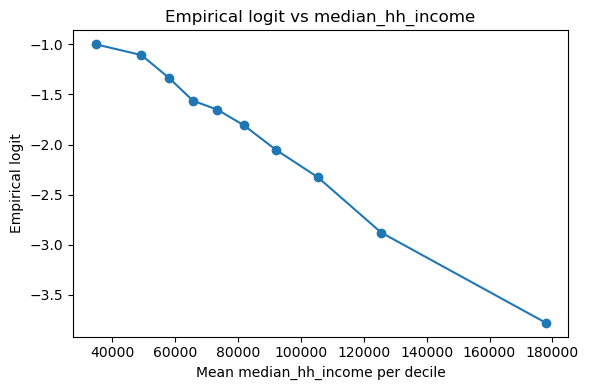

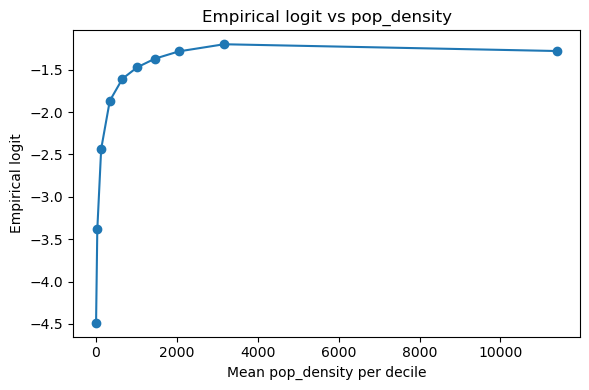

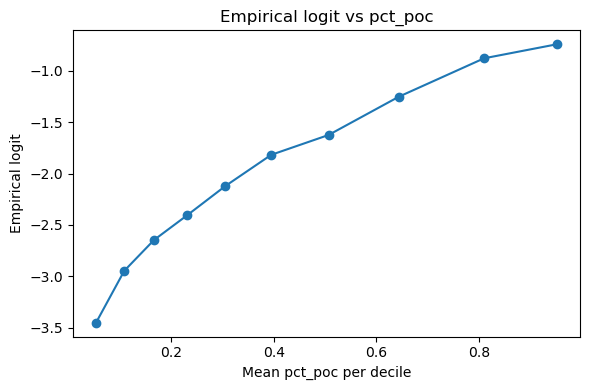

In [24]:
# ── 2. Linearity-in-the-logit: empirical logit by decile ────────────────
def empirical_logit_plot(data, predictor, outcome, n_bins=10):
    d = data.copy()
    d["bin"] = pd.qcut(d[predictor], q=n_bins, duplicates="drop")
    grouped = d.groupby("bin", observed=True).agg(
        mean_x=(predictor, "mean"),
        n=(outcome, "size"),
        successes=(outcome, "sum")
    )
    # add 0.5 to avoid log(0) issues at extreme bins
    grouped["prop"] = (grouped["successes"] + 0.5) / (grouped["n"] + 1)
    grouped["logit"] = np.log(grouped["prop"] / (1 - grouped["prop"]))
    plt.figure(figsize=(6, 4))
    plt.plot(grouped["mean_x"], grouped["logit"], marker="o")
    plt.xlabel(f"Mean {predictor} per decile")
    plt.ylabel("Empirical logit")
    plt.title(f"Empirical logit vs {predictor}")
    plt.tight_layout()
    plt.show()
    return grouped

income_bins = empirical_logit_plot(data, INCOME, OUTCOME)
density_bins = empirical_logit_plot(data, DENSITY, OUTCOME)
poc_bins = empirical_logit_plot(data, PCT_POC, OUTCOME)
# Look for a straight-line relationship in each plot.
# A curved/bowed pattern (especially for income & density, which are
# right-skewed) suggests a log transform is needed.


Population density is looking like it will need to be transformed.

In [25]:
# ── 3. Box-Tidwell test ───────────────────────────────────────────────────
# Adds x*ln(x) interaction terms; a significant coefficient on the
# interaction term indicates non-linearity in the logit for that predictor.
# Requires strictly positive values — shift if you have zeros.
bt_data = data.copy()
for var in [INCOME, DENSITY]:
    if (bt_data[var] <= 0).any():
        bt_data[var] = bt_data[var] - bt_data[var].min() + 1  # shift to positive
    bt_data[f"{var}_lnx"] = bt_data[var] * np.log(bt_data[var])

bt_formula = (
    f"{OUTCOME} ~ {INCOME} + {DENSITY} + {PCT_POC} "
    f"+ {INCOME}_lnx + {DENSITY}_lnx"
)
bt_model = smf.logit(bt_formula, data=bt_data).fit()
print("\n--- Box-Tidwell test ---")
print(bt_model.summary())
# Check p-values on the "_lnx" interaction terms:
# significant (p < 0.05) => that predictor should be log-transformed


Optimization terminated successfully.
         Current function value: 0.366166
         Iterations 8

--- Box-Tidwell test ---
                             Logit Regression Results                             
Dep. Variable:     budget_carrier_present   No. Observations:                82913
Model:                              Logit   Df Residuals:                    82907
Method:                               MLE   Df Model:                            5
Date:                    Tue, 08 Sep 2026   Pseudo R-squ.:                  0.1263
Time:                            12:29:04   Log-Likelihood:                -30360.
converged:                           True   LL-Null:                       -34748.
Covariance Type:                nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -3.299

Rows remaining after log transform: 82913


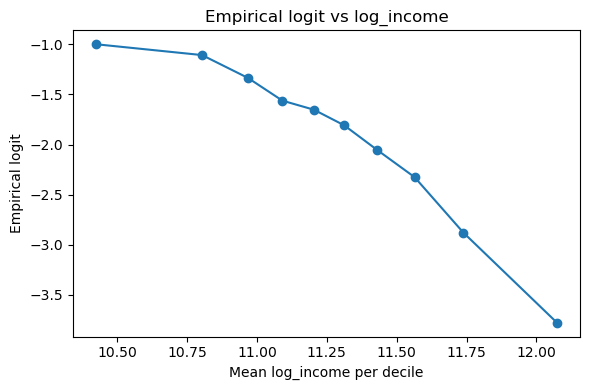

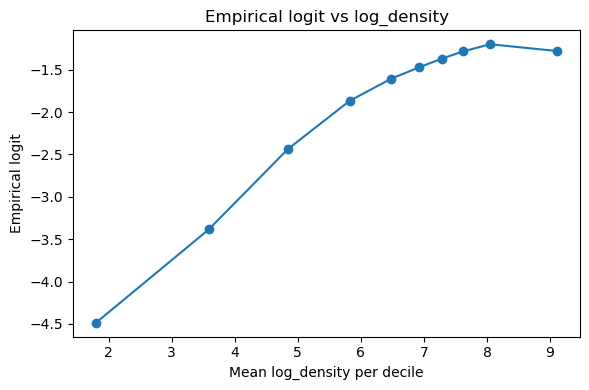

,mean_x,n,successes,prop,logit
bin,,,,,
"(-4.6080000000000005, 2.931]",1.802874,8292,92.0,0.011154,-4.484742
"(2.931, 4.243]",3.588518,8291,271.0,0.032742,-3.385794
"(4.243, 5.396]",4.846339,8291,667.0,0.080499,-2.435583
"(5.396, 6.203]",5.824084,8291,1109.0,0.133804,-1.867738
"(6.203, 6.727]",6.480609,8292,1384.0,0.166948,-1.607413
"(6.727, 7.108]",6.925124,8291,1546.0,0.186505,-1.472881
"(7.108, 7.45]",7.280911,8291,1678.0,0.202424,-1.371212
"(7.45, 7.806]",7.622770,8291,1797.0,0.216775,-1.284559
"(7.806, 8.357]",8.049347,8291,1918.0,0.231368,-1.200605


In [26]:
# ── 4. If a log transform is needed, re-run VIF and empirical logit ──────
data["log_income"] = np.log(data[INCOME])
data["log_density"] = np.log(data[DENSITY].replace(0, np.nan))  # avoid log(0)


# drop any rows where log_density became NaN (i.e., density was 0)
data = data.dropna(subset=["log_income", "log_density"]).copy()
print(f"Rows remaining after log transform: {len(data)}")



# Re-check empirical logit on log scale
empirical_logit_plot(data.dropna(subset=["log_density"]), "log_income", OUTCOME)
empirical_logit_plot(data.dropna(subset=["log_density"]), "log_density", OUTCOME)


In [27]:
# ── 5. Fit the final logistic regression ──────────────────────────────

# final model uses log-transformed income and density, pct_poc untransformed
final_formula = f"{OUTCOME} ~ log_income + log_density + {PCT_POC}"
final_model = smf.logit(final_formula, data=data).fit()
print(final_model.summary())

odds_ratios = np.exp(final_model.params)
conf_int = np.exp(final_model.conf_int())
conf_int['odds_ratio'] = odds_ratios
conf_int.columns = ['2.5%', '97.5%', 'odds_ratio']
print(conf_int)

Optimization terminated successfully.
         Current function value: 0.364693
         Iterations 7
                             Logit Regression Results                             
Dep. Variable:     budget_carrier_present   No. Observations:                82913
Model:                              Logit   Df Residuals:                    82909
Method:                               MLE   Df Model:                            3
Date:                    Tue, 08 Sep 2026   Pseudo R-squ.:                  0.1298
Time:                            12:29:15   Log-Likelihood:                -30238.
converged:                           True   LL-Null:                       -34748.
Covariance Type:                nonrobust   LLR p-value:                     0.000
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       7.7547      0.263     29.500      0.000       7.240       

In [28]:
# % change in odds for a doubling of the original (untransformed) variable
for var in ['log_income', 'log_density']:
    pct_change = (np.exp(final_model.params[var] * np.log(2)) - 1) * 100
    print(f"Doubling {var.replace('log_', '')} is associated with a {pct_change:.1f}% change in odds")

# % change in odds for a 10-percentage-point increase in pct_poc
pct_change_poc = (np.exp(final_model.params['pct_poc'] * 0.10) - 1) * 100
print(f"A 10-point increase in pct_poc is associated with a {pct_change_poc:.1f}% change in odds")

Doubling income is associated with a -51.9% change in odds
Doubling density is associated with a 18.3% change in odds
A 10-point increase in pct_poc is associated with a 14.7% change in odds


# Classification accuracy and a confusion matrix — how often does the model's predicted probability actually match the real outcome?

In [29]:
data['predicted_prob'] = final_model.predict(data)
data['predicted_class'] = (data['predicted_prob'] >= 0.5).astype(int)

from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(data[OUTCOME], data['predicted_class']))
print(classification_report(data[OUTCOME], data['predicted_class']))

[[69587  1061]
 [11699   566]]
              precision    recall  f1-score   support

         0.0       0.86      0.98      0.92     70648
         1.0       0.35      0.05      0.08     12265

    accuracy                           0.85     82913
   macro avg       0.60      0.52      0.50     82913
weighted avg       0.78      0.85      0.79     82913



# ROC and AUC - how well the model ranks tracts by predicted risk, independent of any particular probability cutoff:

AUC: 0.771


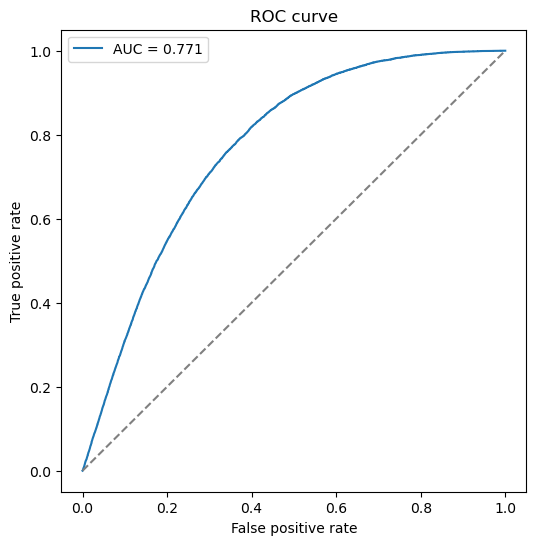

In [30]:
from sklearn.metrics import roc_auc_score, roc_curve

auc = roc_auc_score(data[OUTCOME], data['predicted_prob'])
print(f"AUC: {auc:.3f}")

fpr, tpr, thresholds = roc_curve(data[OUTCOME], data['predicted_prob'])
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.legend()
plt.show()

# Hosmer-Lemeshow goodness-of-fit test — specifically checks whether your predicted probabilities match observed outcome rates across risk groups (unlike pseudo R², which doesn't directly test calibration). 

i.e .whether its predicted probabilities are trustworthy in an absolute sense.

In [31]:
def hosmer_lemeshow(data, outcome_col, prob_col, n_groups=10):
    d = data.copy()
    d['group'] = pd.qcut(d[prob_col], q=n_groups, duplicates='drop')
    grouped = d.groupby('group', observed=True).agg(
        observed=(outcome_col, 'sum'),
        expected=(prob_col, 'sum'),
        n=(outcome_col, 'size')
    )
    grouped['observed_neg'] = grouped['n'] - grouped['observed']
    grouped['expected_neg'] = grouped['n'] - grouped['expected']
    hl_stat = (((grouped['observed'] - grouped['expected'])**2 / grouped['expected']) +
               ((grouped['observed_neg'] - grouped['expected_neg'])**2 / grouped['expected_neg'])).sum()
    from scipy.stats import chi2
    p_value = 1 - chi2.cdf(hl_stat, n_groups - 2)
    return hl_stat, p_value

hl_stat, hl_p = hosmer_lemeshow(data, OUTCOME, 'predicted_prob')
print(f"Hosmer-Lemeshow stat: {hl_stat:.2f}, p-value: {hl_p:.4f}")

Hosmer-Lemeshow stat: 1009.70, p-value: 0.0000


# Takeaway

So the logistic regression tells us that income, density, and % POC are strongly associated variables for whether a budget carrier is present in a census tract. When we convert the log-odds coefficients into odds ratios, we see that 

- Doubling income is associated with a -51.9% change in odds
- Doubling density is associated with a 18.3% change in odds
- A 10-point increase in pct_poc is associated with a 14.7% change in odds


The model shows good discriminative power (AUC = 0.771), meaning it reliably ranks tracts by relative likelihood of budget carrier presence. However, Hosmer-Lemeshow testing indicated imperfect calibration (χ² = 1009.70, p < 0.000), suggesting predicted probabilities don't perfectly match observed rates across all risk levels. At a  standard 0.5 classification threshold, the model performs poorly at flagging individual tracts likely to have a budget carrier present (only 566 of 12,265 actual positive tracts correctly identified), a result of class imbalance (only 14.8% of tracts are positive) rather than a failure of the modeling approach itself. Truthfully, prediction was less important for this exercise than understanding which demographic factors are associated with budget carrier presence and by how much, so the logistic regression was a good first step. 


Now, I think we are ready to think about which types of neigbhorhoods are associated with each carrier. What geodemographic type is associated with each carrier? Regionalization, clustering, or segmentation is the next method I want to explore. 

# GEODEMOGRAPHICS 
# Q3: What are the types of neigbhorhoods based on these variables and how do they correspond to the cellphone carriers?

In [33]:
# recompute derived variables across the full dataset (fixes NY's gap from the earlier geometry splice)
US_Tracts_Carriers['area_sqkm'] = US_Tracts_Carriers.geometry.area / 1_000_000
US_Tracts_Carriers['pop_density'] = US_Tracts_Carriers['total_pop'] / US_Tracts_Carriers['area_sqkm']
US_Tracts_Carriers['children_per_hh'] = US_Tracts_Carriers['own_children'] / US_Tracts_Carriers['total_households']
US_Tracts_Carriers['marriage_rate'] = (US_Tracts_Carriers['married_male'] + US_Tracts_Carriers['married_female']) / US_Tracts_Carriers['pop_15plus']
US_Tracts_Carriers['single_person_share'] = US_Tracts_Carriers['single_person_hh'] / US_Tracts_Carriers['total_households']
US_Tracts_Carriers['pct_nh_white'] = US_Tracts_Carriers['nh_white'] / US_Tracts_Carriers['total_race_universe']
US_Tracts_Carriers['pct_nh_black'] = US_Tracts_Carriers['nh_black'] / US_Tracts_Carriers['total_race_universe']
US_Tracts_Carriers['pct_nh_asian'] = US_Tracts_Carriers['nh_asian'] / US_Tracts_Carriers['total_race_universe']
US_Tracts_Carriers['pct_hispanic'] = US_Tracts_Carriers['hispanic_any_race'] / US_Tracts_Carriers['total_race_universe']



In [34]:
# exporting gdf to csv since it took a while to load this from the census api

US_Tracts_Carriers_export = US_Tracts_Carriers.copy()
US_Tracts_Carriers_export['geometry'] = US_Tracts_Carriers_export['geometry'].to_wkt()
US_Tracts_Carriers_export.to_csv('/Users/gusstephens/Desktop/old Desktop/CellphoneClass/output.csv', index=False)

/var/folders/4m/ym9gy1qd72l1_pyq4z0__91c0000gn/T/ipykernel_2384/1656431167.py:4: UserWarning: Geometry column does not contain geometry.
  US_Tracts_Carriers_export['geometry'] = US_Tracts_Carriers_export['geometry'].to_wkt()


Tracts available for clustering: 82913


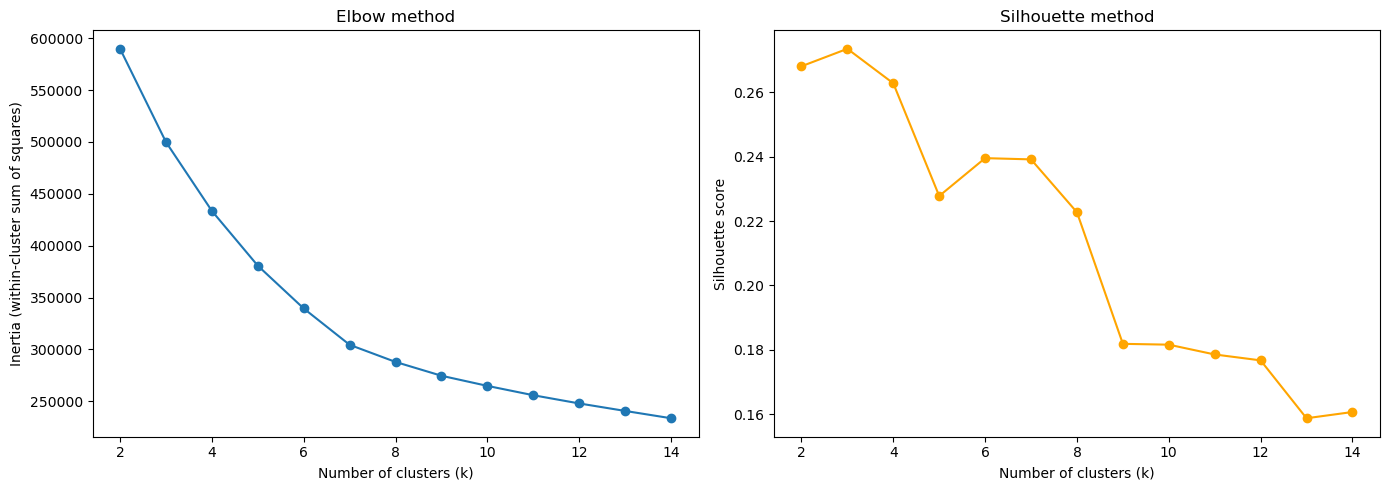

     k        inertia  silhouette
0    2  589696.974204    0.268057
1    3  499796.867194    0.273478
2    4  433439.397013    0.262768
3    5  380663.551083    0.227776
4    6  339451.775266    0.239531
5    7  304437.200232    0.239147
6    8  287940.033610    0.222723
7    9  274633.194705    0.181878
8   10  264866.857225    0.181621
9   11  255871.017566    0.178577
10  12  247952.740059    0.176742
11  13  240734.013834    0.158775
12  14  233689.365900    0.160712


In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# demographic variables to cluster on
cluster_vars = [
    'median_hh_income', 'pop_density', 'children_per_hh', 'marriage_rate',
    'single_person_share', 'pct_nh_white', 'pct_nh_black', 'pct_nh_asian', 'pct_hispanic'
]

# drop tracts with missing values in any clustering variable
cluster_data = US_Tracts_Carriers[['GEOID'] + cluster_vars].dropna().copy()
print(f"Tracts available for clustering: {len(cluster_data)}")

# K-means is distance-based, so variables need to be on the same scale (Z score in this case)—
# without this, income (tens of thousands) would completely dominate
# variables like marriage_rate (0 to 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_data[cluster_vars])

# ── Elbow method: plot within-cluster sum of squares (inertia) for k=2 to 15 ── to find optimal number of clusters
inertias = []
silhouette_scores = []
k_range = range(2, 15)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, marker='o')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia (within-cluster sum of squares)')
axes[0].set_title('Elbow method')

axes[1].plot(k_range, silhouette_scores, marker='o', color='orange')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette method')

plt.tight_layout()
plt.show()

print(pd.DataFrame({'k': list(k_range), 'inertia': inertias, 'silhouette': silhouette_scores}))

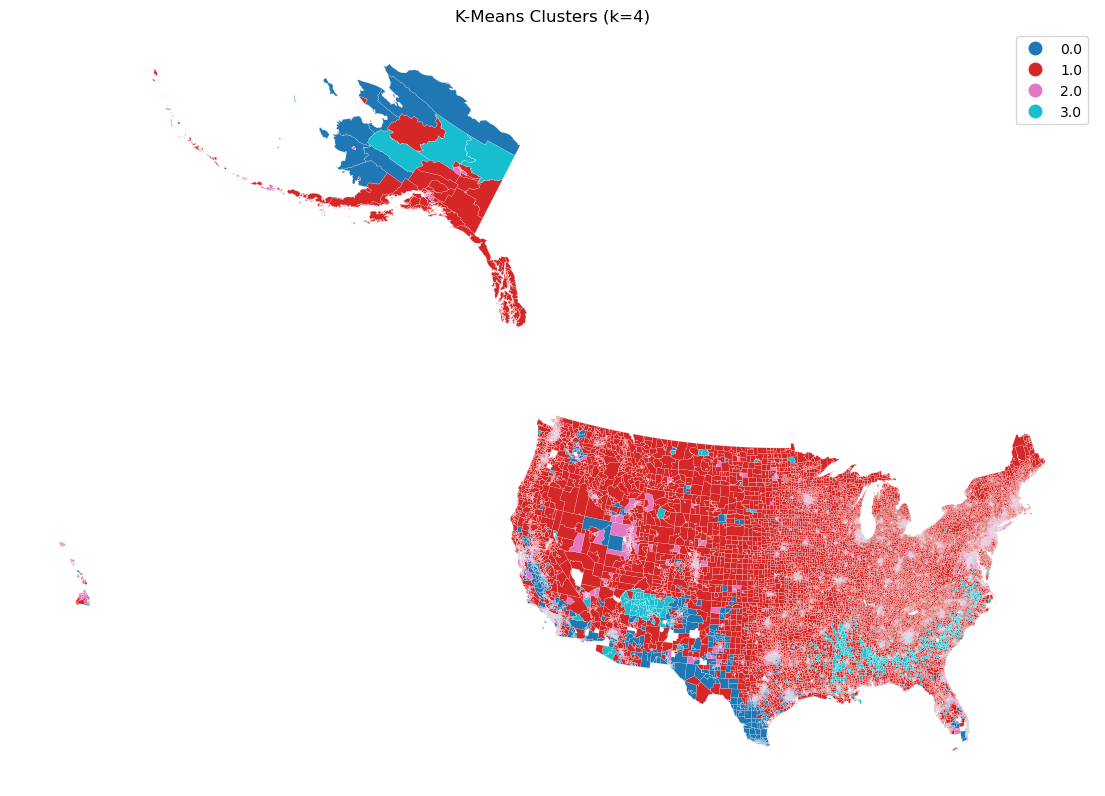

In [37]:
optimal_k = 4  # elbow method suggests 4-6, silhoutte method suggests 3, followed by 4

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_data['cluster'] = kmeans_final.fit_predict(X_scaled)

# merge cluster assignments back onto the full spatial dataframe
US_Tracts_Carriers = US_Tracts_Carriers.merge(
    cluster_data[['GEOID', 'cluster']], on='GEOID', how='left'
)

# map of clusters, like your first reference image
fig, ax = plt.subplots(figsize=(14, 10))
US_Tracts_Carriers.plot(column='cluster', categorical=True, legend=True, ax=ax, cmap='tab10', linewidth=0.1, edgecolor='white')
ax.set_title(f'K-Means Clusters (k={optimal_k})')
ax.axis('off')
plt.show()

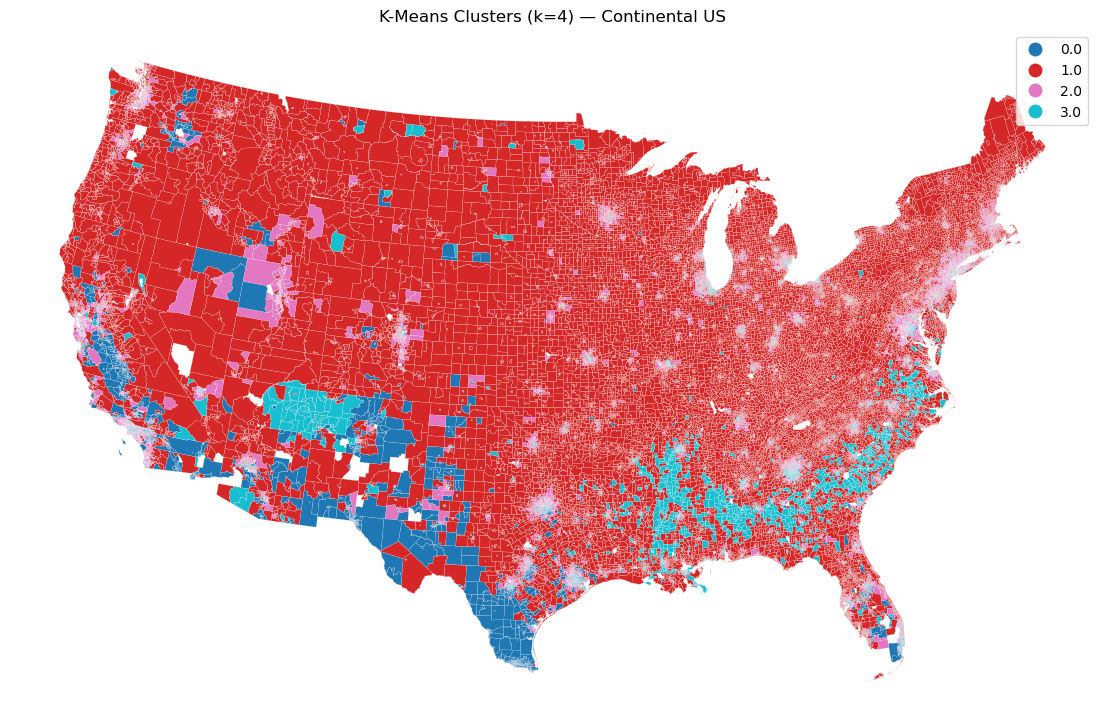

In [38]:
optimal_k = 4  # elbow method suggests 4-6, silhouette method suggests 3, followed by 4

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_data['cluster'] = kmeans_final.fit_predict(X_scaled)

# drop any previous cluster-related columns before merging in the fresh one
cluster_cols_to_drop = [col for col in US_Tracts_Carriers.columns if col.startswith('cluster')]
US_Tracts_Carriers = US_Tracts_Carriers.drop(columns=cluster_cols_to_drop)

# merge cluster assignments back onto the full spatial dataframe
US_Tracts_Carriers = US_Tracts_Carriers.merge(
    cluster_data[['GEOID', 'cluster']], on='GEOID', how='left'
)

# filter to continental US only — exclude Alaska (02), Hawaii (15), and territories (60s/66/69/72/78)
excluded_fips = ['02', '15', '60', '66', '69', '72', '78']
conus = US_Tracts_Carriers[~US_Tracts_Carriers['GEOID'].str[:2].isin(excluded_fips)]

# map of clusters, restricted to CONUS
fig, ax = plt.subplots(figsize=(14, 10))
conus.plot(column='cluster', categorical=True, legend=True, ax=ax, cmap='tab10', linewidth=0.1, edgecolor='white')
ax.set_title(f'K-Means Clusters (k={optimal_k}) — Continental US')
ax.axis('off')
plt.show()

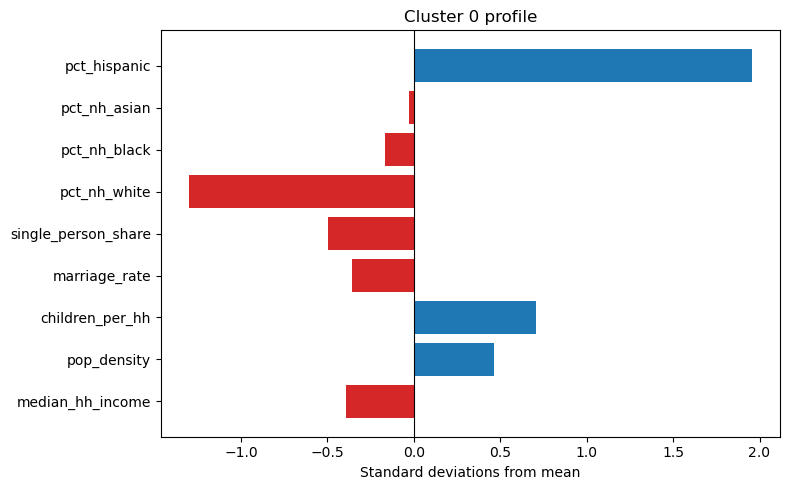

In [40]:
# cluster profile: mean of each (already-scaled) variable within each cluster
cluster_data_with_scaled = cluster_data.copy()
for i, var in enumerate(cluster_vars):
    cluster_data_with_scaled[f'{var}_scaled'] = X_scaled[:, i]

scaled_cols = [f'{var}_scaled' for var in cluster_vars]
cluster_profiles = cluster_data_with_scaled.groupby('cluster')[scaled_cols].mean()
cluster_profiles.columns = cluster_vars  # rename back to readable names

# plot profile for a single cluster, e.g. cluster 0
def plot_cluster_profile(cluster_id):
    profile = cluster_profiles.loc[cluster_id]
    fig, ax = plt.subplots(figsize=(8, 5))
    colors = ['tab:red' if v < 0 else 'tab:blue' for v in profile.values]
    ax.barh(profile.index, profile.values, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Standard deviations from mean')
    ax.set_title(f'Cluster {cluster_id} profile')
    plt.tight_layout()
    plt.show()

plot_cluster_profile(0)

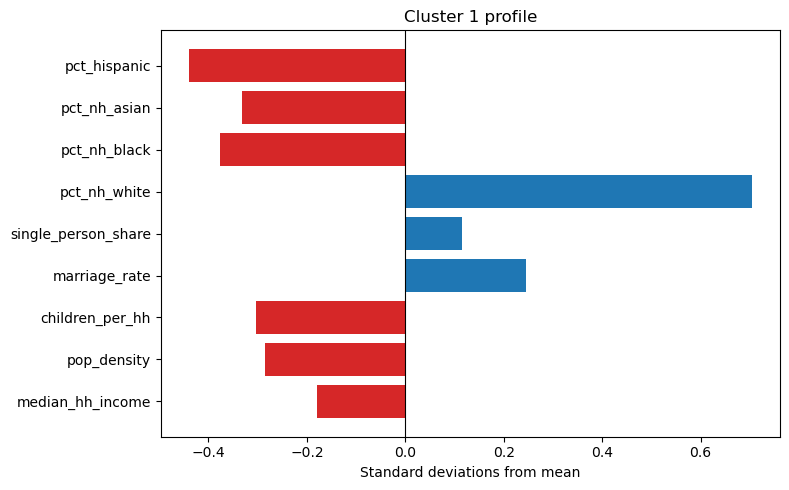

In [41]:
plot_cluster_profile(1)

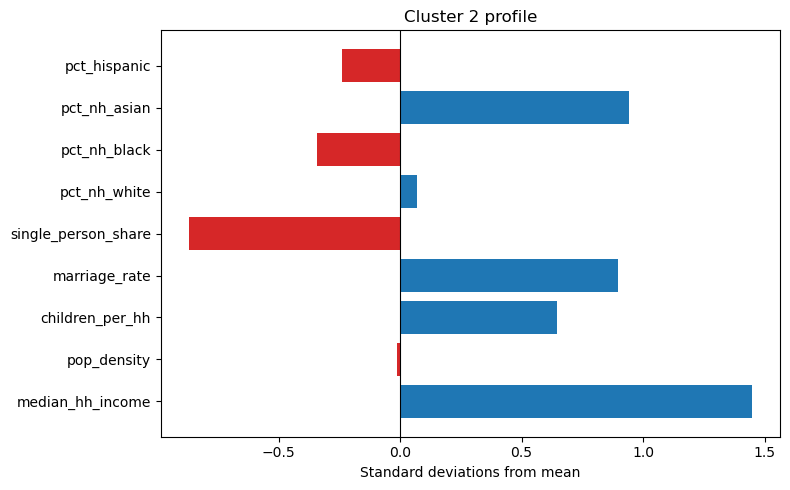

In [42]:
plot_cluster_profile(2)

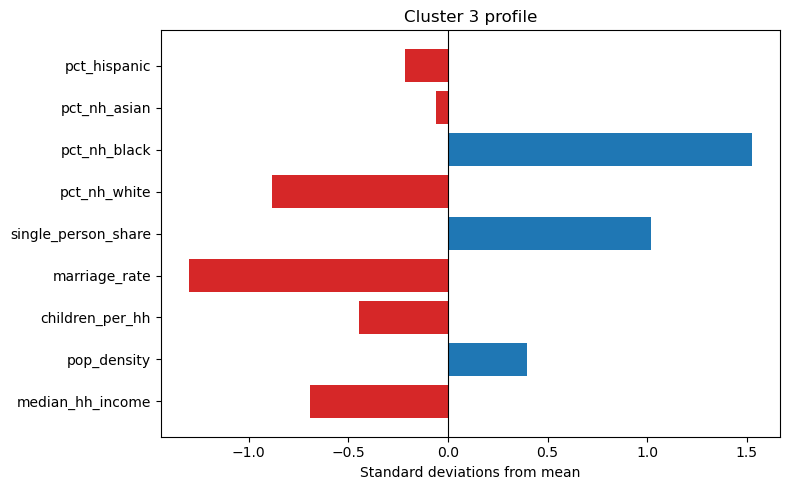

In [43]:
plot_cluster_profile(3)

In [47]:
# medians of the actual (unscaled) demographic variables, by cluster
cluster_medians = US_Tracts_Carriers.groupby('cluster')[cluster_vars].median()
print(cluster_medians)

        median_hh_income  pop_density  children_per_hh  marriage_rate  \
cluster                                                                 
0.0              68125.0  2327.730098         0.641357       0.441930   
1.0              76101.5   252.514168         0.426488       0.528357   
2.0             139250.0  1024.453549         0.627542       0.615438   
3.0              52175.0  1661.470416         0.376504       0.317305   

         single_person_share  pct_nh_white  pct_nh_black  pct_nh_asian  \
cluster                                                                  
0.0                 0.215927      0.173118      0.050909      0.021214   
1.0                 0.291327      0.815652      0.019125      0.007942   
2.0                 0.167225      0.642555      0.026540      0.083196   
3.0                 0.402290      0.323508      0.407048      0.015474   

         pct_hispanic  
cluster                
0.0          0.597602  
1.0          0.055941  
2.0          0.10280

Cluster 0 tracts are characterized by very above average Hispanic populations 
and moderately above average children per household and population densities. 
Non-Hispanic White populations are very below average, and Asian, Black, single 
persons, marriage rates, and household incomes are below average.

Cluster 1 tract populations have above average non-Hispanic White, single 
people, and marriage rates, but below average Hispanics, Asian, Black, 
children, population densities, and median household incomes.

Cluster 2 is characterized by very above average incomes and Asian populations, 
above average children and marriage rates, and non-Hispanic Whites. Single 
people are very below average, and Hispanics and Blacks are below average; 
population densities are below average, but only ever so slightly.

Cluster 3 is characterized by very above average Black populations and single 
populations. Cross-referencing the map, this cluster appears to include 
historically Black Belt tracts in the South and Native reservation tracts, 
along with lower-income urban tracts that may be undergoing demographic 
change. Population densities are above average. Marriage rates are very 
below average. Incomes and White populations are below average. Hispanic, 
Asian, and children are slightly below average.

Cluster 0: Hispanic sunbelt neighborhoods with large families

Cluster 1: White heartland, rural/exurban neighborhoods

Cluster 2: High income, high marriage rates with children, usually Asian 
or White

Cluster 3: Singles, Black populations, lower incomes -- includes historical 
Black Belt and Western Reservation tracts, as well as lower-income tracts 
in major cities that may reflect a mix of long-term disinvestment and 
early-stage neighborhood change.

In [48]:
distances = kmeans_final.transform(X_scaled)  # distance from each point to every centroid
sorted_distances = np.sort(distances, axis=1)
ambiguity = sorted_distances[:, 0] / sorted_distances[:, 1]  # closer to 1 = more ambiguous
cluster_data['ambiguity_ratio'] = ambiguity
print(cluster_data['ambiguity_ratio'].describe())

count    82913.000000
mean         0.618737
std          0.210937
min          0.103056
25%          0.447542
50%          0.604596
75%          0.797629
max          0.999986
Name: ambiguity_ratio, dtype: float64


**Caveat on cluster interpretation**

These four clusters are best understood as summaries of typical demographic 
patterns, not as sharply bounded or mutually exclusive categories. K-means 
assigns each tract to the cluster whose average (centroid) it is closest to 
across all nine standardized demographic variables simultaneously -- not 
based on any single defining trait, but on overall similarity to that 
cluster's typical profile.

Because this is a hard-assignment method, every tract is placed into exactly 
one cluster regardless of how close or far it actually sits from that 
cluster's center -- there is no "doesn't fit well" category. Diagnostic 
checks on this clustering solution (silhouette score ≈ 0.27; median ratio of 
a tract's distance to its nearest versus second-nearest cluster ≈ 0.60) 
indicate that cluster boundaries are not sharply defined: a meaningful share 
of tracts sit closer to a boundary between two clusters than to their 
assigned cluster's clear center, and could plausibly have been grouped 
differently under a slightly different set of variables or model 
specification.

As a result, the cluster labels and descriptions above (e.g., "Hispanic 
sunbelt neighborhoods," "White heartland, rural/exurban") should be read as 
characterizations of each cluster's central tendency, not as claims that 
every tract within a cluster matches that description closely, or that 
tracts in different clusters are demographically distinct in every respect.

# How neighborhood categories breakdown by carrier

In [45]:
# ── Table 1: cluster share breakdown by carrier ──────────────────────────
# for each carrier, what % of tracts where that carrier is present falls in each cluster
carrier_cluster_shares = {}

for carrier in carrier_cols:
    present = US_Tracts_Carriers[US_Tracts_Carriers[carrier] > 0]
    shares = present['cluster'].value_counts(normalize=True).sort_index() * 100
    carrier_cluster_shares[carrier] = shares

carrier_cluster_table = pd.DataFrame(carrier_cluster_shares).T
carrier_cluster_table.columns = [f'Cluster {int(c)}' for c in carrier_cluster_table.columns]
carrier_cluster_table = carrier_cluster_table.round(1)
print(carrier_cluster_table)

# ── Table 2: cluster share breakdown by budget carrier status ────────────
budget_cluster_shares = {}

for status, label in [(1, 'Budget carrier present'), (0, 'No budget carrier')]:
    subset = US_Tracts_Carriers[US_Tracts_Carriers['budget_carrier_present'] == status]
    shares = subset['cluster'].value_counts(normalize=True).sort_index() * 100
    budget_cluster_shares[label] = shares

budget_cluster_table = pd.DataFrame(budget_cluster_shares).T
budget_cluster_table.columns = [f'Cluster {int(c)}' for c in budget_cluster_table.columns]
budget_cluster_table = budget_cluster_table.round(1)
print(budget_cluster_table)

              Cluster 0  Cluster 1  Cluster 2  Cluster 3
MetroPCS           37.8       24.9        5.7       31.5
Cricket            33.2       38.4        4.8       23.6
Boost Mobile       35.4       26.8        3.6       34.2
AT&T               13.5       50.4       19.2       16.9
Sprint             17.3       40.3       17.8       24.6
TMobile            19.7       42.3       18.1       19.9
Verizon            10.8       53.1       21.1       15.0
                        Cluster 0  Cluster 1  Cluster 2  Cluster 3
Budget carrier present       33.9       30.8        5.6       29.7
No budget carrier            11.9       51.5       20.9       15.7


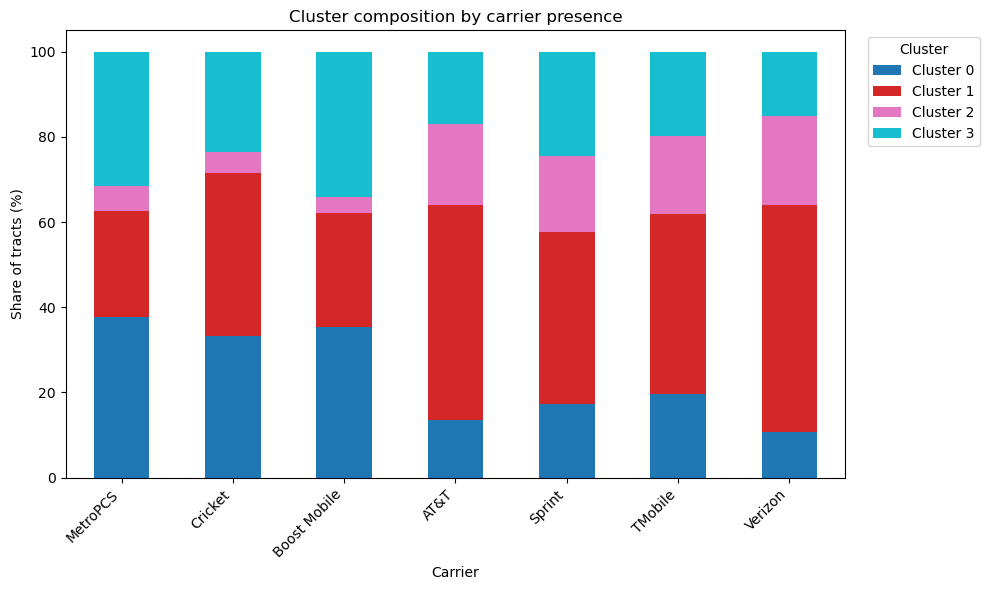

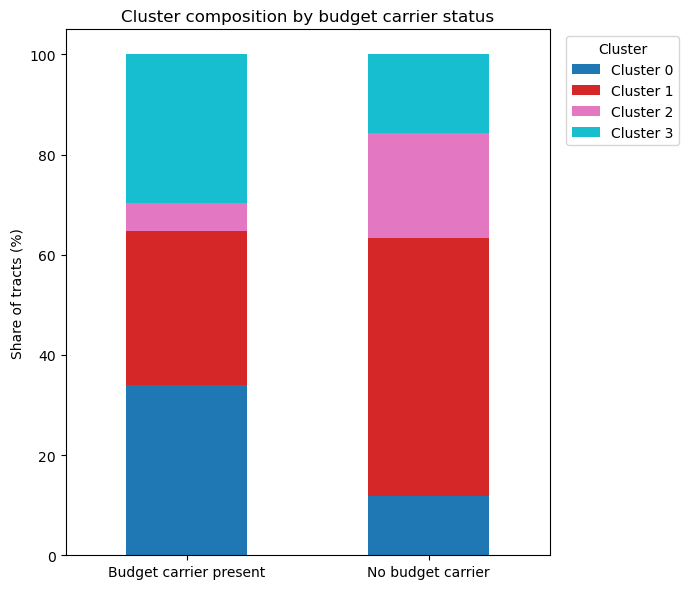

In [46]:
# ── Visualization 1: stacked bar — cluster share by carrier ──────────────
fig, ax = plt.subplots(figsize=(10, 6))
carrier_cluster_table.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
ax.set_ylabel('Share of tracts (%)')
ax.set_xlabel('Carrier')
ax.set_title('Cluster composition by carrier presence')
ax.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ── Visualization 2: stacked bar — cluster share by budget carrier status ─
fig, ax = plt.subplots(figsize=(7, 6))
budget_cluster_table.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
ax.set_ylabel('Share of tracts (%)')
ax.set_xlabel('')
ax.set_title('Cluster composition by budget carrier status')
ax.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

But are these differences in category shares signficant? First let's test if distribution is indepent of carrier presence with a chi-square test.

We can look at the Cramér's V (effect size) to see how strong the association is (scaled 0-1). This is important because Chi-square raw value scale up mechanically with sample size. In other words, is this difference meaningful.

In [49]:
from scipy.stats import chi2_contingency
import numpy as np

# ── Chi-square test: is cluster distribution independent of carrier presence? ──
for carrier in carrier_cols:
    present = US_Tracts_Carriers[US_Tracts_Carriers[carrier] > 0]['cluster']
    absent = US_Tracts_Carriers[US_Tracts_Carriers[carrier] == 0]['cluster']
    
    contingency = pd.crosstab(
        US_Tracts_Carriers[carrier] > 0,
        US_Tracts_Carriers['cluster']
    )
    
    chi2, p, dof, expected = chi2_contingency(contingency)
    
    # Cramér's V: effect size for chi-square (0 = no association, 1 = perfect association)
    n = contingency.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
    
    print(f"{carrier}: chi2={chi2:.1f}, p={p:.4g}, Cramér's V={cramers_v:.3f}")

MetroPCS: chi2=4850.1, p=0, Cramér's V=0.242
Cricket: chi2=1679.5, p=0, Cramér's V=0.142
Boost Mobile: chi2=3607.1, p=0, Cramér's V=0.209
AT&T: chi2=17.7, p=0.0005154, Cramér's V=0.015
Sprint: chi2=19.1, p=0.0002566, Cramér's V=0.015
TMobile: chi2=165.0, p=1.538e-35, Cramér's V=0.045
Verizon: chi2=52.4, p=2.47e-11, Cramér's V=0.025


MetroPCS and Boost Mobile show a small-to-medium association; Cricket shows a small association; AT&T, Sprint, Verizon, and TMobile show negligible associations. T-Mobile, AT&T, and Verizon don't have a meaningful association, which makes sense as the largest/widest network in the US.

We can look at the standardized residuals to see where the association is is coming from.

In [51]:
# ── Standardized residuals: which cluster(s) drive the association for each carrier ──
for carrier in carrier_cols:
    contingency = pd.crosstab(
        US_Tracts_Carriers[carrier] > 0,
        US_Tracts_Carriers['cluster']
    )
    chi2, p, dof, expected = chi2_contingency(contingency)
    
    residuals = (contingency - expected) / np.sqrt(expected)
    print(f"\n{carrier} standardized residuals:")
    print(residuals.round(2))
    # |residual| > ~2 is generally considered a notably large deviation from independence


MetroPCS standardized residuals:
cluster    0.0    1.0    2.0    3.0
MetroPCS                           
False    -14.5   8.40   7.41  -8.07
True      48.3 -27.98 -24.70  26.90

Cricket standardized residuals:
cluster    0.0   1.0    2.0   3.0
Cricket                          
False    -7.35  2.28   5.08 -2.18
True     30.93 -9.59 -21.38  9.18

Boost Mobile standardized residuals:
cluster         0.0    1.0    2.0    3.0
Boost Mobile                            
False         -9.85   5.90   6.58  -7.37
True          37.80 -22.62 -25.23  28.29

AT&T standardized residuals:
cluster   0.0   1.0   2.0   3.0
AT&T                           
False    0.79 -0.52 -0.24  0.37
True    -3.09  2.02  0.93 -1.44

Sprint standardized residuals:
cluster   0.0   1.0   2.0   3.0
Sprint                         
False   -0.09  0.18  0.03 -0.25
True     1.17 -2.45 -0.41  3.39

TMobile standardized residuals:
cluster   0.0   1.0   2.0   3.0
TMobile                        
False   -2.66  2.01  0.26 -1.12
True

The large negative residuals for MetroPCS, Boost Mobile, and  Cricket, in clusters 1 and 2, mean they are underrepresented in the White rural/exurban heartland neighborhoods and in the high income/high marriage neighborhoods. The budget carriers ahve large positive residuals for clusers 0 and 3, the Hispanic Sunbelt tracts and the majority-Black, single-person, lower-income tracts tracts, meaning they are over represented. MetroPCS, in particular, has the largest residual for Cluster 0 (Hispanic Sunbelt tracts). 

The legacy carriers have much smaller positive and negative residuals, suggesting less over/under representation, although T-Mobile's residual in cluster 0 is relatively high (9.3), which might indicate greater targeting of service/presence in these neighborhoods. 

Despite these large residuals for MetroPCS and Boost Mobile, the overall Cramér's V (0.242 and 0.209, respectively) indicates the cluster-carrier association, while real and directionally consistent, is only small-to-medium in overall strength.

Because seven separate chi-square tests were run (one per carrier), a 
Bonferroni correction was applied to guard against the increased chance of 
a false positive that comes from testing multiple hypotheses at once. This 
adjusts the significance threshold from the standard α = 0.05 down to 
α = 0.05 / 7 ≈ 0.0071, meaning only p-values below this stricter cutoff are 
treated as significant.

In [52]:
from scipy.stats import chi2_contingency

alpha = 0.05
bonferroni_alpha = alpha / len(carrier_cols)
print(f"Bonferroni-corrected significance threshold: {bonferroni_alpha:.4f}")

Bonferroni-corrected significance threshold: 0.0071


Every one of the carriers' p-values came in far below even this stricter threshold (the largest, Sprint's, was 0.0005154), so the correction didn't change our finding about cluster category and carrier not being independent of one another.

In [53]:
# export tracts with cluster categories to a csv for future analysis

US_Tracts_Carriers_export = US_Tracts_Carriers.copy()
US_Tracts_Carriers_export['geometry'] = US_Tracts_Carriers_export['geometry'].to_wkt()
US_Tracts_Carriers_export.to_csv(
    '/Users/gusstephens/Desktop/old Desktop/CellphoneClass/US_Tracts_Carriers_with_clusters.csv',
    index=False
)

/var/folders/4m/ym9gy1qd72l1_pyq4z0__91c0000gn/T/ipykernel_2384/2754185229.py:2: UserWarning: Geometry column does not contain geometry.
  US_Tracts_Carriers_export['geometry'] = US_Tracts_Carriers_export['geometry'].to_wkt()


# Interpretation

To formally test whether cluster membership (neighborhood type) differs meaningfully by carrier 
presence, chi-square tests of independence were run for each carrier against 
the four-cluster typology, with a Bonferroni correction applied for multiple 
comparisons (α = 0.0071). All seven carriers showed statistically significant 
associations, but effect sizes (Cramér's V) revealed a clear divide: the three 
budget carriers -- MetroPCS (V=0.242), Boost Mobile (V=0.209), and Cricket 
(V=0.142) -- showed small-to-medium, substantively meaningful associations 
with cluster membership, while the four traditional carriers -- AT&T, Sprint, 
TMobile, and Verizon -- showed associations that were statistically 
significant only due to the large sample size (V ranging from 0.015 to 0.045), 
and are not practically meaningful.

Standardized residuals showed a consistent pattern across all three budget 
carriers: tracts with MetroPCS, Boost Mobile, or Cricket present were 
significantly overrepresented in Cluster 0 (Hispanic sunbelt neighborhoods 
with large families) and Cluster 3 (majority-Black, lower-income, single-
person tracts), and significantly underrepresented in Cluster 1 (White, 
married, lower-density tracts) and Cluster 2 (high-income, high-marriage-rate 
tracts). This finding is consistent with the earlier logistic regression 
result, in which pct_poc showed the strongest positive association with 
budget carrier presence among all tested predictors.